#Judul : Memprediksi Pengunjung Wisatawan Mancanegara ke Bali melalui Bandara Ngurah Rai

#Pendahuluan

##Latar Belakang

Bandara Ngurah Rai, yang terletak di Bali, merupakan salah satu pintu gerbang utama bagi wisatawan mancanegara ke Indonesia. Sebagai bandara internasional, Ngurah Rai memegang peran krusial dalam sektor pariwisata Bali karena sebagian besar wisatawan internasional tiba melalui bandara ini. Bali, khususnya melalui Bandara Ngurah Rai, terkenal dengan kekayaan budaya, keindahan alam, dan atraksi wisata yang beragam seperti pantai, candi, dan kesenian tradisional.

Selama beberapa dekade, Bali telah dikenal sebagai "Pulau Dewata" dan menjadi tujuan wisata favorit bagi wisatawan internasional. Namun, berbagai faktor global seperti dinamika ekonomi, perubahan preferensi wisatawan, kebijakan perjalanan, serta pandemi global telah memberikan dampak signifikan terhadap arus kunjungan wisatawan melalui Bandara Ngurah Rai.

Peningkatan atau penurunan kunjungan melalui Bandara Ngurah Rai dipengaruhi oleh beberapa aspek, termasuk kebijakan visa, promosi pariwisata, keamanan, infrastruktur, dan tren global. Bali memiliki visi menjadi destinasi wisata berkelanjutan yang mampu menarik wisatawan secara konsisten dengan memberikan layanan berkualitas tinggi, pengalaman unik, dan menjaga kelestarian lingkungan. Misinya adalah untuk mengoptimalkan infrastruktur dan layanan pariwisata demi memenuhi kebutuhan wisatawan internasional.

Oleh karena itu, memprediksi tren kunjungan wisatawan mancanegara melalui Bandara Ngurah Rai menjadi hal yang penting bagi pemerintah daerah dan industri pariwisata. Dengan analisis prediktif, pemangku kepentingan dapat menyusun strategi jangka panjang untuk meningkatkan daya tarik pariwisata Bali sekaligus mengantisipasi tantangan yang muncul. Langkah ini juga membantu dalam merancang kebijakan dan inisiatif baru untuk memperkuat sektor pariwisata, mempertahankan daya saing, dan memastikan keberlanjutan pariwisata Bali.

##Tujuan

Tujuan dari proyek ini adalah untuk dapat membuat model Memprediksi Pengunjung Wisatawan Mancanegara ke Bali melalui Bandara Ngurah Rai . Dengan menggunakan metode time series, Model ini diharapkan mampu meprediksi pengunjung mancanegara dari bulan ke bulan sehingga dapat digunakan dalam membantu pemerintah daerah dan pelaku industri pariwisata untuk menyiapkan strategi guna meningkatkan daya tarik Bali, serta mengantisipasi tantangan yang mungkin timbul.

##Rumusan Masalah

Bagaimana cara untuk membangun model yang akurat dalam memprediksi pengunjung wisatawan mancanegara ke Bali?

#Metodologi

##Memahami Data

Saya memperoleh data ini dari Bada Pusat Statistik Provinsi Bali, dengan rentang Bulan Januari tahun 2009 hingga Bulan Agustus 2024 sehingga berjumlah 188 data. Data ini akan digunakan untuk keperluan analisis tren dan pola, sebagai acuan dalam pengambilan keputusan serta perencanaan yang lebih efektif di masa mendatang.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px


# File ID dari Google Drive
file_id = '1QWBIgJcJxcoBpZ7jidLMiuX27Kk6TnRS'

# Membuat URL unduhan langsung
url = f'https://drive.google.com/uc?id={file_id}'

# Membaca CSV dari link
df = pd.read_csv(url)

# Menampilkan total data
total_data = df.shape[0]
print("Total data:", total_data)

# Menampilkan data
df.head()

Total data: 188


,Date,Pengunjung
0,1/31/2009,173867.0
1,2/28/2009,146115.0
2,3/31/2009,167954.0
3,4/30/2009,188189.0
4,5/31/2009,190638.0


In [2]:
# Menampilkan tipe data setiap kolom
print("\nTipe data setiap kolom:")
print(df.dtypes)


Tipe data setiap kolom:
Date           object
Pengunjung    float64
dtype: object


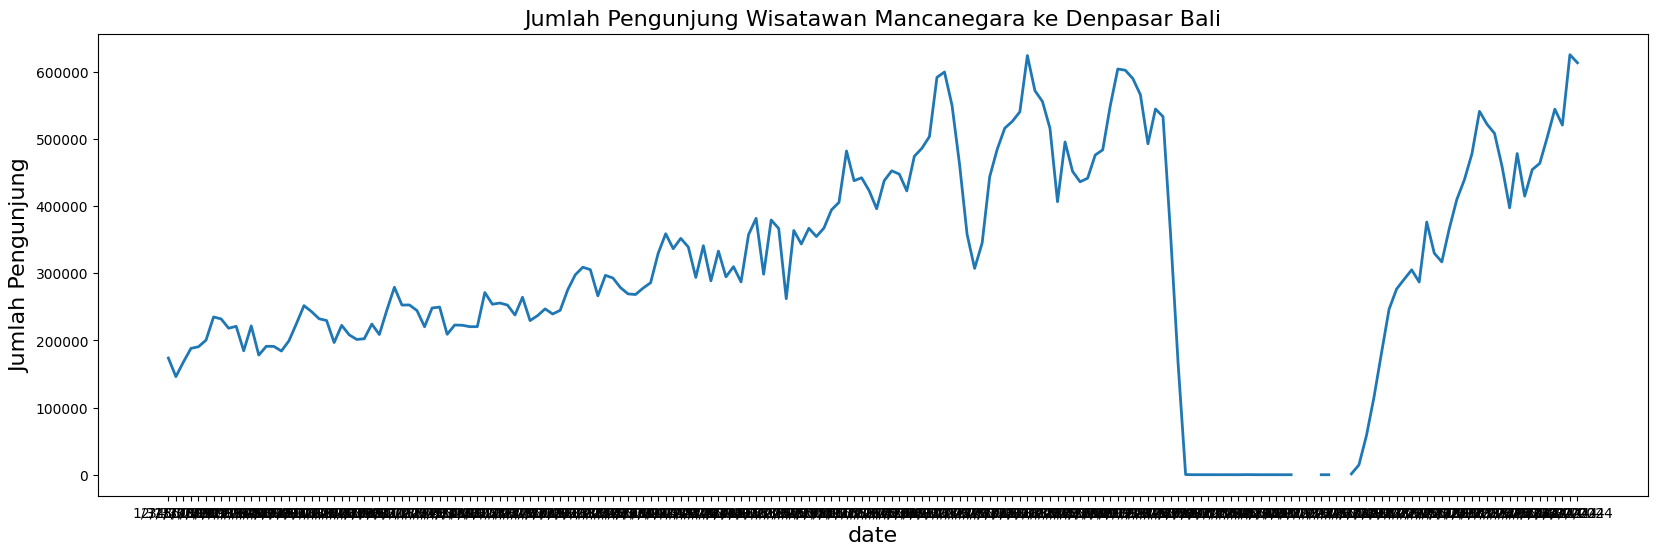

In [3]:
#plotting data
plt.figure(figsize=(20,6))
plt.plot(df["Date"], df['Pengunjung'], lw=2)
plt.xlabel("date")
plt.xlabel("date", fontsize=16)
plt.ylabel("Jumlah Pengunjung", fontsize=16)
plt.title("Jumlah Pengunjung Wisatawan Mancanegara ke Denpasar Bali", fontsize=16);

data yang saya dapatkan merupakan tipe data yang non-linear

##Praproses Data

###Mengubah Format Date Menjadi Datetime

In [4]:
#Ubah format Date yang awalnya object menjadi Datetime
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Pengunjung
0,2009-01-31,173867.0
1,2009-02-28,146115.0
2,2009-03-31,167954.0
3,2009-04-30,188189.0
4,2009-05-31,190638.0


###Mengecek Data Duplikat
Mengecek data duplikat adalah langkah pertama yang penting untuk memastikan tidak ada baris yang terulang dalam dataset. Data duplikat dapat menyebabkan model belajar dari data yang sama lebih dari sekali, yang bisa menurunkan performa model. Anda dapat menggunakan fungsi seperti duplicated() atau drop_duplicates() pada DataFrame untuk menemukan dan menghapus duplikat.

In [5]:
# Mengecek apakah ada data yang sama
print(df.duplicated().sum())

0


###Mengecek Data Hilang
Data hilang (missing values) bisa memengaruhi akurasi model. Sebelum melanjutkan ke langkah pemodelan, sangat penting untuk memeriksa apakah ada nilai yang hilang dalam dataset dan menangani mereka dengan cara yang sesuai. Misalnya, Anda dapat mengisi nilai yang hilang dengan nilai rata-rata, median, atau mode, atau bahkan menghapus baris yang mengandung data hilang jika jumlahnya sedikit.


In [6]:
print(df.isnull().sum())

Date          0
Pengunjung    5
dtype: int64


###Menghapus Data Kosong
Pada saat mengecek data hilang dan didapati hanya 5 data saja, jadi saya memilih untuk menghapusnya saja

In [7]:
# Menghapus nilai yang kosong
df = df.dropna(subset=['Pengunjung'])

Dilakukan pengecekan ulang

In [8]:
print(df.isnull().sum())

Date          0
Pengunjung    0
dtype: int64


###Sliding Window

Sliding Window adalah sebuah teknik yang digunakan untuk menyelesaikan berbagai masalah algoritma, terutama yang melibatkan data urutan (seperti array atau string). Teknik ini bekerja dengan cara menggeser sebuah window (jendela) sepanjang data dan melakukan operasi tertentu di setiap posisi jendela tersebut.

In [9]:
df_slide = df.copy()

In [10]:
def sliding_window(data, lag):
    series = data['Pengunjung']
    result = pd.DataFrame()
    for l in lag:
        result[f'xt-{l}'] = series.shift(l)

    result['xt'] = series[l:]
    result = result.dropna()
    result.index = series.index[l:]  # Mengatur index sesuai dengan nilai lag
    return result


df_slide = sliding_window(df, [1, 2, 3])
df_slide["Date"] = df["Date"].iloc[len(df["Date"]) - len(df_slide):].values

# Mengatur ulang urutan kolom
df_slide = df_slide[['Date', 'xt', 'xt-1', 'xt-2', 'xt-3']]

# Menampilkan hasil
df_slide.head()

,Date,xt,xt-1,xt-2,xt-3
3,2009-04-30,188189.0,167954.0,146115.0,173867.0
4,2009-05-31,190638.0,188189.0,167954.0,146115.0
5,2009-06-30,200503.0,190638.0,188189.0,167954.0
6,2009-07-31,234984.0,200503.0,190638.0,188189.0
7,2009-08-31,232090.0,234984.0,200503.0,190638.0


Deskripsi Data

xt-3 : data 3 bulan sebelum data target atau xt

xt-2 : data 2 bulan sebelum data target atau xt

xt-1 : data 1 bulan sebelum data target atau xt

xt : data bulan yang digunakan sebagai target

In [11]:
# Melihat nilai minimum dan maksimum pada setiap kolom
min_values = df_slide.min()
max_values = df_slide.max()

print("Nilai Minimum:\n", min_values)
print("\nNilai Maksimum:\n", max_values)

Nilai Minimum:
 Date    2009-04-30 00:00:00
xt                      1.0
xt-1                    1.0
xt-2                    1.0
xt-3                    1.0
dtype: object

Nilai Maksimum:
 Date    2024-08-31 00:00:00
xt                 625569.0
xt-1               625569.0
xt-2               624337.0
xt-3               624337.0
dtype: object


###Mengubah kolom Date menjadi index


In [12]:
df_slide = df_slide.set_index('Date')

###Visualisasi Data

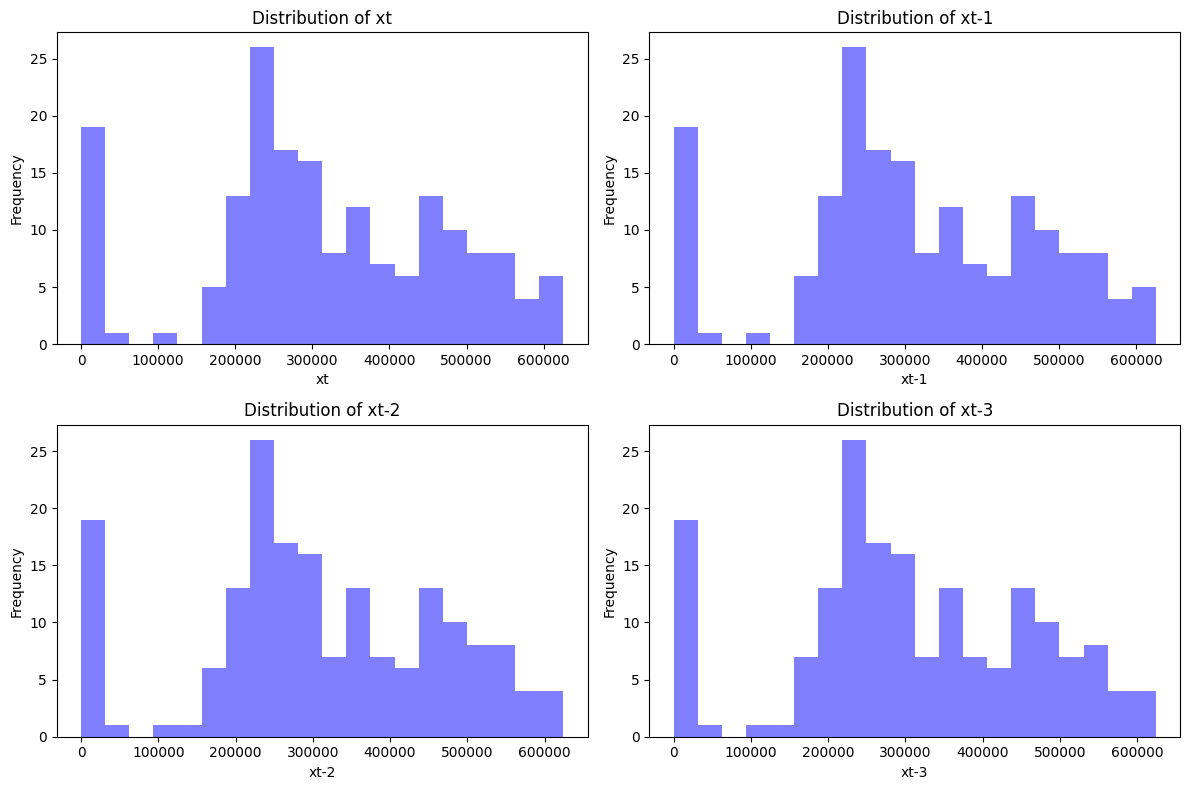

In [13]:
# Mengambil semua kolom fitur
features = list(df_slide.columns)

# Menghitung jumlah subplot yang diperlukan
num_features = len(features)
num_rows = (num_features + 1) // 2  # Pembulatan ke atas untuk jumlah baris

# Membuat subplot sesuai dengan jumlah fitur
fig, axs = plt.subplots(num_rows, 2, figsize=(12, num_rows*4))

# Melakukan plotting untuk setiap fitur
for i, feature in enumerate(features):
    row = i // 2
    col = i % 2
    axs[row, col].hist(df_slide[feature], bins=20, color='blue', alpha=0.5)
    axs[row, col].set_title(f'Distribution of {feature}')
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel('Frequency')

# Menghapus subplot yang tidak terpakai
if num_features % 2 == 1:
    fig.delaxes(axs[num_rows-1, 1])

# Menyesuaikan layout
plt.tight_layout()

# Menampilkan plot
plt.show()

<ipython-input-14-86099c3a1f80>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(features))


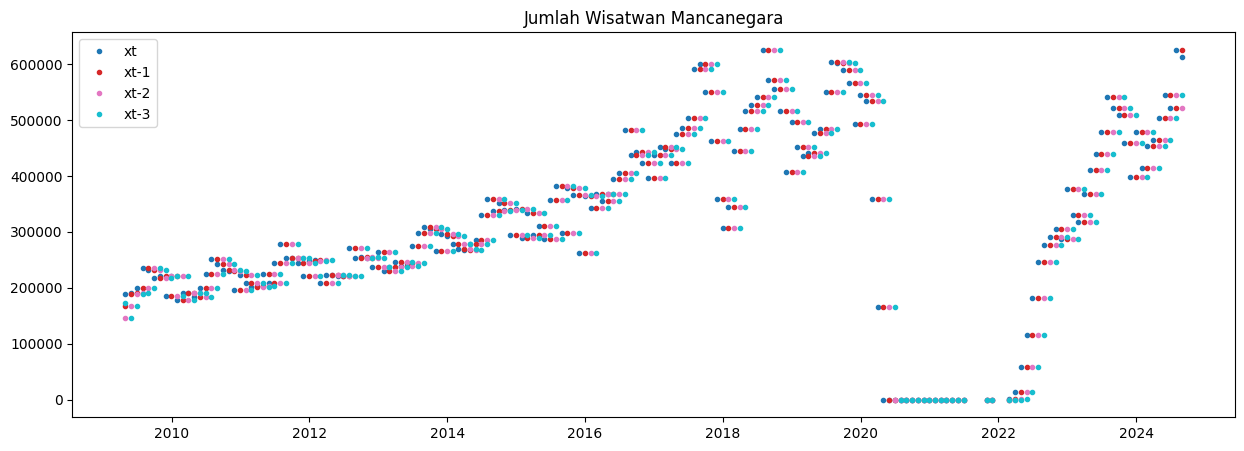

In [14]:
# df_slide['xt'].plot()

features = df_slide.columns
colors = plt.cm.get_cmap('tab10', len(features))
plt.figure(figsize=(15, 5))

for i, feature in enumerate(features):
    plt.plot(df_slide.index, df_slide[feature], linestyle='', marker='.', color=colors(i), label=feature)
plt.title('Jumlah Wisatwan Mancanegara')
plt.legend()
# plt.xticks(rotation=90)
plt.show()

###Pengecekan missing Value
Dilakukan pengecekan kembali agar data benar benar tidak memiliki missing value

In [15]:
print(df_slide.isnull().sum())

xt      0
xt-1    0
xt-2    0
xt-3    0
dtype: int64


###Pengecekan Outlier
Outlier (pencilan) adalah nilai yang jauh berbeda dari nilai lainnya dalam dataset. Outlier dapat mempengaruhi model prediksi, terutama jika model sangat sensitif terhadap nilai ekstrem. Oleh karena itu, penting untuk mendeteksi outlier, baik menggunakan teknik statistik seperti IQR (Interquartile Range) atau visualisasi seperti box plot.

Disini saya menggunakan IQR, Interquartile Range (IQR) adalah ukuran statistik yang digunakan untuk menggambarkan rentang nilai tengah dari dataset dan membantu dalam mendeteksi outlier. IQR dihitung sebagai selisih antara Kuartil Ketiga (Q3) dan Kuartil Pertama (Q1), yaitu :



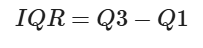

Kuartil :
* Kuartil pertama (Q1) adalah nilai yang membagi 25% data terendah. Ini adalah nilai pada posisi ke-25% dalam urutan data yang terurut.
* Kuartil ketiga (Q3) adalah nilai yang membagi 25% data tertinggi. Ini adalah nilai pada posisi ke-75% dalam urutan data yang terurut.
* Median (Q2) adalah nilai yang membagi dataset menjadi dua bagian yang sama (50%).

Fungsi IQR :

IQR menggambarkan seberapa tersebar data dalam kuartil tengah, yaitu 50% data yang terletak di antara Q1 dan Q3. Karena IQR mengabaikan nilai ekstrim (outlier), maka IQR sangat berguna untuk mendeteksi dan mengatasi outlier dalam dataset yang terdistribusi tidak normal atau memiliki data ekstrim.

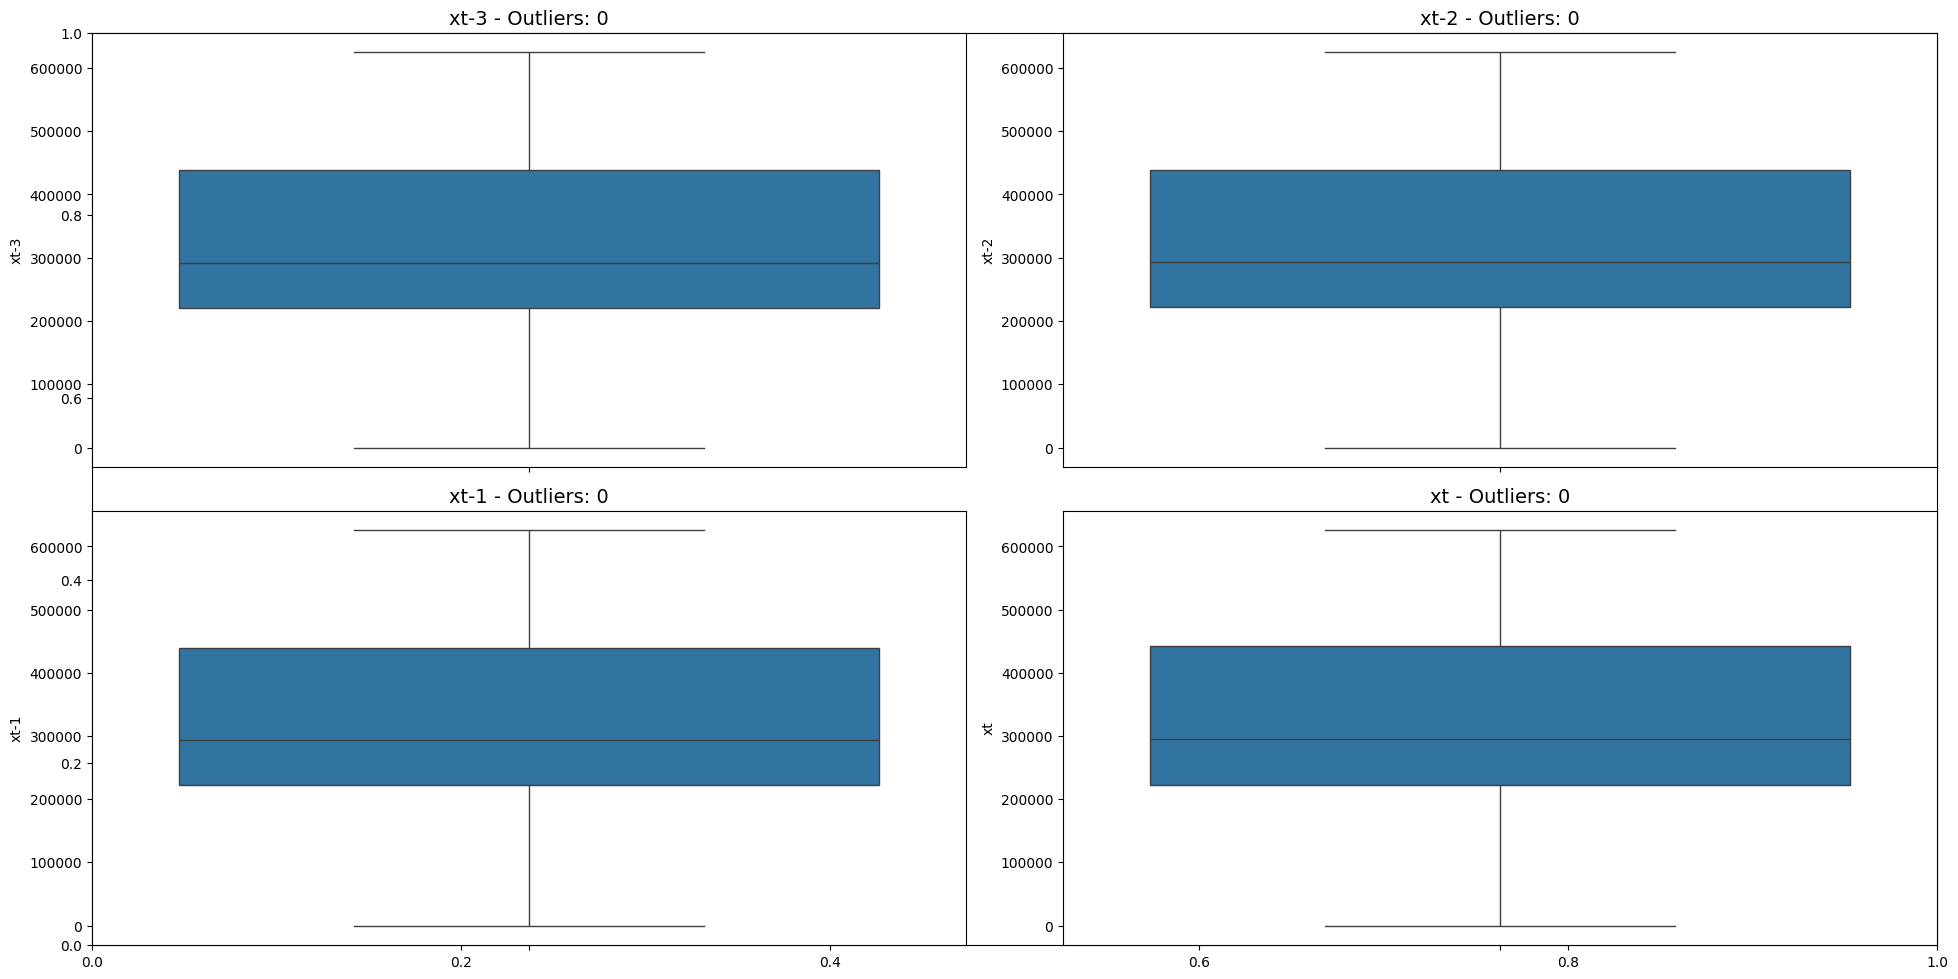

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Daftar fitur yang dianalisis
features = ['xt-3', 'xt-2', 'xt-1', 'xt']

# Fungsi untuk menghitung jumlah outlier menggunakan IQR
def count_outliers(data):
    Q1 = np.percentile(data, 25)  # Kuartil pertama (Q1)
    Q3 = np.percentile(data, 75)  # Kuartil ketiga (Q3)
    IQR = Q3 - Q1  # Rentang interkuartil

    lower_bound = Q1 - 1.5 * IQR  # Batas bawah
    upper_bound = Q3 + 1.5 * IQR  # Batas atas

    # Hitung jumlah outlier
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers)

# Plot boxplot dengan jumlah outlier
plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sb.boxplot(df_slide[col])

    # Hitung jumlah outlier untuk setiap kolom
    num_outliers = count_outliers(df_slide[col])

    # Tambahkan teks jumlah outlier ke plot
    plt.title(f'{col} - Outliers: {num_outliers}', fontsize=14)

plt.tight_layout()
plt.show()

Dapat dilihat, data tidak memiliki outlier jadi tidak perlu adanya penghapusan outlier

###Normalisasi Data
Normalisasi data diperlukan untuk skala yang konsisten di antara fitur-fitur yang berbeda.

Disini saya menggunakan MinMaxScaler, MinMaxScaler adalah salah satu metode normalisasi yang mengubah skala data agar berada dalam rentang tertentu, biasanya antara 0 dan 1.

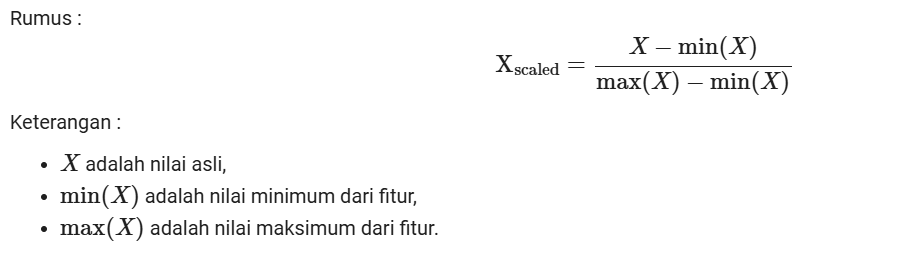

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi semua kolom kecuali indeks
df_normalized = pd.DataFrame(scaler.fit_transform(df_slide), columns=df_slide.columns, index=df_slide.index)

df_normalized.head()

,xt,xt-1,xt-2,xt-3
Date,,,,
2009-04-30,0.300827,0.268481,0.234031,0.278481
2009-05-31,0.304742,0.300827,0.269011,0.234031
2009-06-30,0.320512,0.304742,0.301421,0.269011
2009-07-31,0.375631,0.320512,0.305344,0.301421
2009-08-31,0.371005,0.375631,0.321144,0.305344


###Melakukan Filtering Untuk Data Yang Mendekati Nilai 0 atau Sama Dengan 0

In [18]:
# Menentukan ambang batas
threshold = 1e-3  # Nilai mendekati 0, misalnya 0.001

# Memfilter data yang nilai absolutnya >= threshold
df_filtered = df_normalized[(np.abs(df_normalized) >= threshold).all(axis=1)]

# Memeriksa hasil
print(df_filtered.head())

                  xt      xt-1      xt-2      xt-3
Date                                              
2009-04-30  0.300827  0.268481  0.234031  0.278481
2009-05-31  0.304742  0.300827  0.269011  0.234031
2009-06-30  0.320512  0.304742  0.301421  0.269011
2009-07-31  0.375631  0.320512  0.305344  0.301421
2009-08-31  0.371005  0.375631  0.321144  0.305344


###Membagi Data Menjadi training dan testing
Pembagian dataset menjadi data pelatihan (training) dan pengujian (testing) adalah langkah penting untuk menghindari overfitting dan memastikan model dapat dievaluasi dengan baik pada data yang belum pernah dilihat sebelumnya.
Dalam analisis kali ini, saya membaginya menjadi 80% untuk pelatihan dan 20% untuk pengujian.

In [19]:
from sklearn.model_selection import train_test_split

X_train_model = df_filtered.drop(columns=['xt'])
y_train_model = df_filtered['xt']

X_train, X_test, y_train, y_test = train_test_split(X_train_model, y_train_model, test_size = 0.2, random_state=42, shuffle=False)

##Pemodelan Data

Disini saya menggunakan 3 model yaitu Regresi linear, RandomForestRegressor, SVR, Neural Network, dan Ensemble Bagging. Berikut penjelasannya :
* Regresi Linear adalah metode statistik yang digunakan untuk memodelkan hubungan antara satu atau lebih fitur independen (variabel input) dan variabel dependen (variabel output). Pada regresi linier, hubungan antara variabel-variabel tersebut diasumsikan linier, artinya perubahan pada variabel input menghasilkan perubahan proporsional pada variabel output.
* Random Forest adalah model ensemble yang menggunakan banyak pohon keputusan untuk melakukan prediksi. Setiap pohon dalam hutan (forest) dibuat dengan memilih subset acak dari fitur dan data training yang berbeda. Prediksi dari setiap pohon kemudian digabungkan untuk memberikan prediksi akhir.
* Support Vector Regression (SVR) adalah algoritma regresi yang menggunakan prinsip-prinsip Support Vector Machine (SVM) untuk regresi. SVR berusaha menemukan garis atau hyperplane yang memiliki margin yang lebih kecil di sekitar data, dengan tujuan meminimalkan kesalahan prediksi.
* Neural Network (Jaringan Saraf Tiruan) adalah model pembelajaran mesin yang terinspirasi oleh cara kerja otak manusia. Model ini terdiri dari lapisan-lapisan yang saling terhubung (dikenal sebagai neuron), yang menerima input, memprosesnya, dan menghasilkan output. Neural Network sangat kuat untuk menangani masalah regresi dan klasifikasi, terutama ketika data memiliki hubungan yang kompleks dan non-linear. Jaringan saraf yang lebih dalam (Deep Learning) memiliki banyak lapisan tersembunyi yang memungkinkan model untuk mempelajari fitur yang lebih abstrak dari data.
* Bagging (Bootstrap Aggregating) adalah teknik ensemble yang melibatkan pembelajaran banyak model secara paralel, di mana setiap model dilatih pada subset acak dari data pelatihan yang diambil dengan penggantian (bootstrap). Prediksi dari setiap model kemudian digabungkan untuk menghasilkan prediksi akhir. Teknik ini mengurangi varians model dan sering digunakan dengan model dasar seperti pohon keputusan. Bagging dapat meningkatkan akurasi model dengan mengurangi overfitting dan meningkatkan kestabilan.



Dan berikut adalah hasil modelnya :

In [20]:
# Fungsi untuk menghitung MAPPE
def calculate_mappe(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true))) * 100

###Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model regresi linier
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred = lr_model.predict(X_test)

# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Menghitung RMSE sebagai akar dari MSE
r2 = r2_score(y_test, y_pred)

# Menghitung MAPE
mape = calculate_mappe(y_test, y_pred)

print("Linear Regression - MAE: {:.4f}".format(mae))
print("Linear Regression - RMSE:{:.4f}".format(rmse))  # Menampilkan RMSE
print("Linear Regression - R2: {:.4f}".format(r2))
print("Linear Regression - MAPE: {:.2f}%".format(mape))

Linear Regression - MAE: 0.0774
Linear Regression - RMSE:0.1037
Linear Regression - R2: 0.7413
Linear Regression - MAPE: 15.32%


###Random Forest

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)  # Menghitung RMSE sebagai akar dari MSE
r2_rf = r2_score(y_test, y_pred_rf)

# Menghitung MAPE
mape_rf = calculate_mappe(y_test, y_pred_rf)

print("Random Forest - MAE: {:.4f}".format(mae_rf))
print("Random Forest - RMSE:{:.4f}".format(rmse_rf))  # Menampilkan RMSE
print("Random Forest - R2: {:.4f}".format(r2_rf))
print("Random Forest - MAPE: {:.2f}%".format(mape_rf))

Random Forest - MAE: 0.0807
Random Forest - RMSE:0.1091
Random Forest - R2: 0.7141
Random Forest - MAPE: 15.42%


###Support Vector Regression (SVR)

In [23]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model SVR
svr_model = SVR(kernel='rbf')  # 'rbf' kernel adalah kernel default
svr_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_svr = svr_model.predict(X_test)

# Evaluasi model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)  # Menghitung RMSE sebagai akar dari MSE
r2_svr = r2_score(y_test, y_pred_svr)

# Menghitung MAPE
mape_svr = calculate_mappe(y_test, y_pred_svr)

# Menampilkan hasil evaluasi
print("SVR - MAE: {:.4f}".format(mae_svr))
print("SVR - RMSE: {:.4f}".format(rmse_svr))  # Menampilkan RMSE
print("SVR - R2: {:.4f}".format(r2_svr))
print("SVR - MAPE: {:.2f}%".format(mape_svr))

SVR - MAE: 0.0980
SVR - RMSE: 0.1401
SVR - R2: 0.5285
SVR - MAPE: 23.72%


####Neural Network

In [24]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model Neural Network
nn_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_nn = nn_model.predict(X_test)

# Evaluasi model
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)  # Menghitung RMSE sebagai akar dari MSE
r2_nn = r2_score(y_test, y_pred_nn)

# Menghitung MAPE
mape_nn = calculate_mappe(y_test, y_pred_nn)

print("Neural Network - MAE: {:.4f}".format(mae_nn))
print("Neural Network - RMSE:{:.4f}".format(rmse_nn))  # Menampilkan RMSE
print("Neural Network - R2: {:.4f}".format(r2_nn))
print("Neural Network - MAPE: {:.2f}%".format(mape_nn))

Neural Network - MAE: 0.0839
Neural Network - RMSE:0.1209
Neural Network - R2: 0.6487
Neural Network - MAPE: 16.77%


###Ensemble Bagging

In [25]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat model regresi linier
base_lr_model = LinearRegression()

# Membuat dan melatih model Bagging dengan base model regresi linier
bagging_model = BaggingRegressor(estimator=base_lr_model, n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_bagging = bagging_model.predict(X_test)

# Evaluasi model
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mse_bagging)  # Menghitung RMSE sebagai akar dari MSE
r2_bagging = r2_score(y_test, y_pred_bagging)

# Menghitung MAPE
mape_bagging = calculate_mappe(y_test, y_pred_bagging)

print("Bagging - MAE: {:.4f}".format(mae_bagging))
print("Bagging - RMSE: {:.4f}".format(rmse_bagging))  # Menampilkan RMSE
print("Bagging - R2: {:.4f}".format(r2_bagging))
print("Bagging - MAPE: {:.2f}%".format(mape_bagging))


Bagging - MAE: 0.0777
Bagging - RMSE: 0.1042
Bagging - R2: 0.7391
Bagging - MAPE: 15.47%


#Evaluasi

Disini saya menggunakan 4 evaluasi yaitu : MAE, RMSE, R2 dan MAPE. Berikut adalah penjelasan lebih lengkapnya

##1. Mean Absolute Error (MAE)
Definisi: MAE mengukur rata-rata dari selisih absolut antara nilai prediksi dan nilai aktual. Ini memberikan gambaran seberapa besar rata-rata kesalahan dalam prediksi model tanpa mempertimbangkan arah kesalahan (apakah prediksi lebih tinggi atau lebih rendah dari nilai aktual).

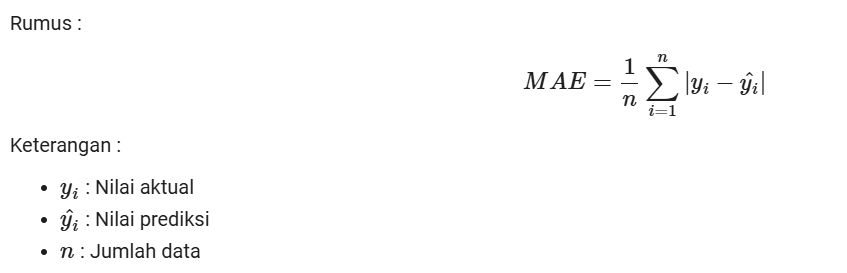

MAE memberikan nilai kesalahan yang mudah dipahami dan digunakan ketika kita ingin mengetahui rata-rata seberapa besar kesalahan dalam prediksi, tanpa terlalu memikirkan apakah prediksi tersebut lebih besar atau lebih kecil dari nilai yang sebenarnya.

##2. RMSE (Root Mean Squared Error)
Definisi: RMSE adalah akar kuadrat dari rata-rata kuadrat selisih antara nilai prediksi dan nilai aktual. RMSE memberi lebih banyak penalti pada kesalahan besar, mirip dengan MSE, tetapi karena diambil akar kuadratnya, RMSE akan berada dalam satuan yang sama dengan data, sehingga lebih mudah dipahami.

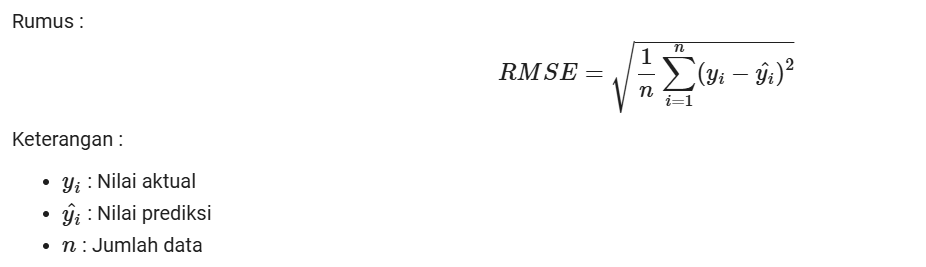

RMSE memberikan penalti yang lebih besar pada kesalahan besar dan sangat sensitif terhadap outlier. Nilai RMSE yang lebih kecil menunjukkan prediksi yang lebih akurat.

##3. R-squared (R²)
Definisi: R² adalah ukuran seberapa baik model dalam menjelaskan variasi dalam data yang diamati. Ini menunjukkan persentase varians dalam data yang dapat dijelaskan oleh model. R² juga dikenal sebagai koefisien determinasi.

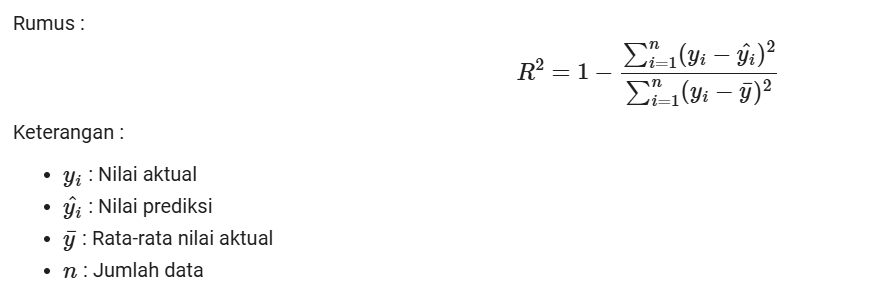

Nilai R² berkisar antara 0 dan 1, dengan 1 menunjukkan bahwa model dapat menjelaskan seluruh variasi dalam data, dan 0 menunjukkan bahwa model tidak dapat menjelaskan variasi lebih baik daripada model rata-rata. R² yang lebih tinggi menunjukkan bahwa model lebih baik dalam menangkap pola dalam data.

##4. Mean Absolute Percentage Error (MAPE)
Definisi: MAPE mengukur kesalahan rata-rata dalam bentuk persentase antara nilai prediksi dan nilai aktual. Ini memberikan gambaran tentang akurasi prediksi dalam persentase, yang memudahkan interpretasi bagi pengguna yang tidak terbiasa dengan unit atau skala data.

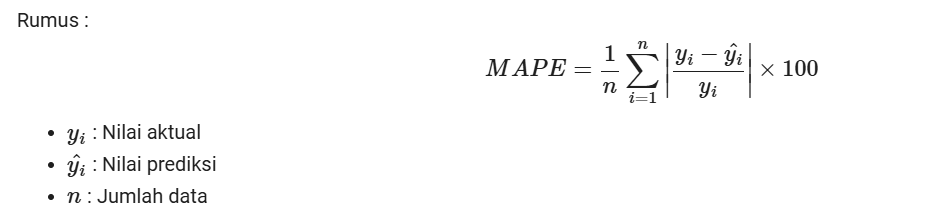

MAPE memberikan persentase kesalahan rata-rata dalam prediksi. Nilai MAPE yang lebih rendah menunjukkan model yang lebih akurat. Nilai MAPE yang tinggi menunjukkan bahwa model sering membuat kesalahan besar.

##Hasil Yang Didapatkan
setelah melakukan pemodelan data menggunakan beberapa algoritma, dilakukan evaluasi terhadap model yang telah dilatih untuk memprediksi jumlah pengunjung di Bali. Berdasarkan hasil evaluasi, model terbaik yang memberikan performa paling optimal adalah Linear Regression.

Hasil Evaluasi dari model Linear Regression yaitu :

* MAE (Mean Absolute Error) = 0.0774, MAE mengukur rata-rata kesalahan absolut antara prediksi dan nilai aktual. Semakin kecil nilai MAE, semakin baik model dalam memprediksi nilai yang dekat dengan nilai sebenarnya. Nilai MAE 0.0774 menunjukkan bahwa model Linear Regression memiliki tingkat kesalahan yang relatif kecil dan dapat memberikan prediksi yang cukup akurat.
* RMSE (Root Mean Square Error) = 0.1037, RMSE memberikan gambaran tentang seberapa besar kesalahan prediksi model dalam satuan yang sama dengan data asli. Nilai RMSE yang rendah menunjukkan model memiliki kesalahan yang kecil, dan Linear Regression dengan nilai 0.1037 menunjukkan bahwa kesalahan prediksi model masih dalam batas yang dapat diterima untuk kasus ini.
* R2 (R-squared) = 0.7413, R-squared menunjukkan seberapa baik model dapat menjelaskan variabilitas data. Nilai R-squared 0.7413 berarti bahwa model Linear Regression dapat menjelaskan sekitar 74% variabilitas dalam data jumlah pengunjung. Angka ini cukup tinggi dan menunjukkan bahwa model memiliki kemampuan yang baik dalam menjelaskan hubungan antara fitur dan jumlah pengunjung.
* MAPE (Mean Absolute Percentage Error) = 15.32%, MAPE mengukur rata-rata persentase kesalahan antara prediksi dan nilai aktual. Nilai MAPE 15.32% berarti bahwa kesalahan rata-rata dalam prediksi jumlah pengunjung adalah sekitar 15%, yang menunjukkan bahwa model Linear Regression dapat memberikan prediksi yang cukup baik meskipun ada kesalahan sekitar 15% dari nilai aktual.


##Visualisasi Hasil Dari Model Linear Regression

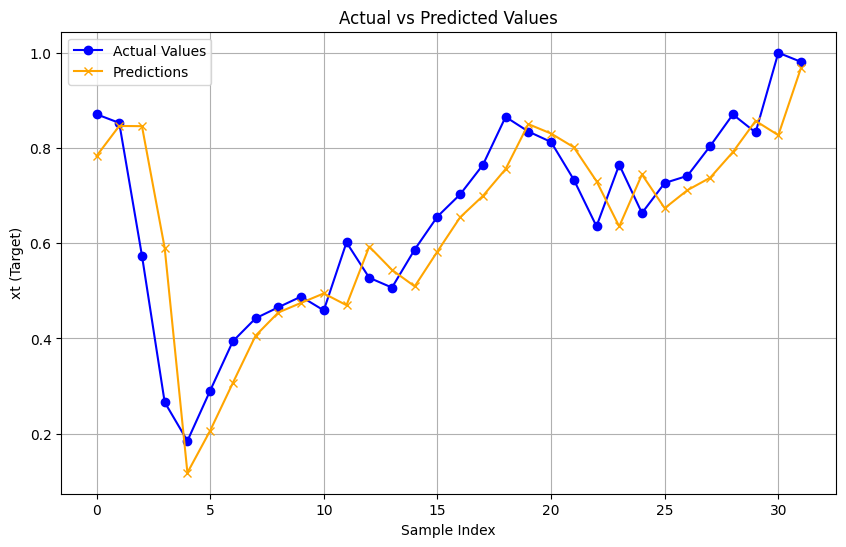

In [26]:
# Visualizing Actual vs Predicted Values
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(range(len(y_test)), y_test, label='Actual Values', color='blue', marker='o')

# Plot predictions
plt.plot(range(len(y_test)), y_pred, label='Predictions', color='orange', marker='x')

# Adding labels and title
plt.xlabel('Sample Index')
plt.ylabel('xt (Target)')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

#Dampak Hasil Analisis

Berdasarkan hasil evaluasi model Linear Regression untuk memprediksi jumlah pengunjung di Bali, beberapa dampak signifikan dapat diperoleh :

##1. Akurasi Prediksi yang Tinggi

Dengan R-squared sebesar 0.7413, model Linear Regression mampu menjelaskan sekitar 74% variabilitas dalam jumlah pengunjung. Ini menunjukkan bahwa model dapat menangkap hubungan antara variabel input (seperti faktor cuaca, event, promosi, atau variabel lainnya) dengan jumlah pengunjung dengan cukup baik. Hasil ini sangat bermanfaat bagi perencanaan dan prediksi jangka panjang terkait jumlah pengunjung di Bali.

##2. Kesalahan Prediksi yang Terkendali

Nilai MAE sebesar 0.0774 dan RMSE sebesar 0.1037 menunjukkan bahwa model tidak menghasilkan kesalahan prediksi yang besar. Kesalahan yang relatif kecil ini menunjukkan bahwa model Linear Regression sangat cocok untuk memprediksi jumlah pengunjung dengan tingkat ketepatan yang tinggi, meskipun ada fluktuasi kecil di data yang mungkin tidak dapat dijelaskan sepenuhnya oleh model.

##2. Prediksi dengan Margin Kesalahan yang Dapat Diterima

Nilai MAPE 15.32% memberikan indikasi bahwa kesalahan rata-rata dalam prediksi jumlah pengunjung sekitar 15%. Meskipun ada kesalahan dalam prediksi, ini masih dianggap wajar dalam banyak kasus prediksi berbasis regresi, terutama untuk data yang mungkin dipengaruhi oleh banyak faktor eksternal dan fluktuasi musiman yang sulit diprediksi dengan tepat.

##3. Potensi untuk Perencanaan dan Pengambilan Keputusan

Hasil yang diperoleh dari model Linear Regression dapat digunakan oleh pihak terkait, seperti pengelola destinasi wisata atau pemangku kebijakan, untuk merencanakan alokasi sumber daya, menentukan strategi pemasaran, atau merancang kebijakan yang dapat meningkatkan jumlah pengunjung. Prediksi yang cukup akurat akan membantu merencanakan event, meningkatkan fasilitas, atau meningkatkan kualitas pengalaman pengunjung.

#Strategi Berdasarkan Hasil Analisis

##1. Pemanfaatan Model Linear Regression untuk Perencanaan Pariwisata:

Mengingat hasil yang baik dari model Linear Regression, strategi pertama yang dapat diterapkan adalah menggunakan model ini untuk perencanaan tahunan dan perkiraan jumlah pengunjung berdasarkan data historis. Misalnya, model ini dapat digunakan untuk merencanakan kapasitas akomodasi, transportasi, dan event pariwisata di Bali.

##2. Optimasi Pengambilan Keputusan Bisnis:

Dengan akurasi model yang cukup baik, strategi bisnis yang berbasis data (data-driven decision making) dapat diterapkan. Misalnya, model ini dapat digunakan untuk:
Mengoptimalkan alokasi sumber daya di sektor pariwisata.
Meningkatkan strategi pemasaran dengan mengetahui kapan puncak pengunjung terjadi.
Menyesuaikan harga tiket dan akomodasi berdasarkan proyeksi jumlah pengunjung.